In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [3]:
features = pd.read_csv("data/alt_acsincome_ca_features_85.csv")
features.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,41.0,4.0,24.0,1.0,2555.0,6.0,1.0,60.0,2.0,1.0
1,77.0,7.0,22.0,1.0,4920.0,39.0,0.0,35.0,1.0,1.0
2,38.0,1.0,18.0,1.0,440.0,6.0,1.0,50.0,1.0,1.0
3,30.0,1.0,22.0,5.0,1555.0,6.0,2.0,80.0,1.0,6.0
4,36.0,1.0,16.0,1.0,4030.0,314.0,1.0,70.0,2.0,1.0


In [4]:
labels = pd.read_csv("data/alt_acsincome_ca_labels_85.csv")
labels.head()

,PINCP
0,True
1,True
2,False
3,True
4,False


In [5]:
dataset = pd.concat([features, labels], axis=1)
dataset.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,41.0,4.0,24.0,1.0,2555.0,6.0,1.0,60.0,2.0,1.0,True
1,77.0,7.0,22.0,1.0,4920.0,39.0,0.0,35.0,1.0,1.0,True
2,38.0,1.0,18.0,1.0,440.0,6.0,1.0,50.0,1.0,1.0,False
3,30.0,1.0,22.0,5.0,1555.0,6.0,2.0,80.0,1.0,6.0,True
4,36.0,1.0,16.0,1.0,4030.0,314.0,1.0,70.0,2.0,1.0,False


In [6]:
shape = dataset.shape

* AGEP: Age
* COW: Class of worker
* SCHL: Educational attainment
* MAR: Marital status
* OCCP: Occupation
* POBP: Place of Birth
* RELP: Relationship
* WKHP: Hours worked per week past 12 months
* SEX: Sex
* RAC1P: Recoded detailed race code
* PINCP: Total person's income

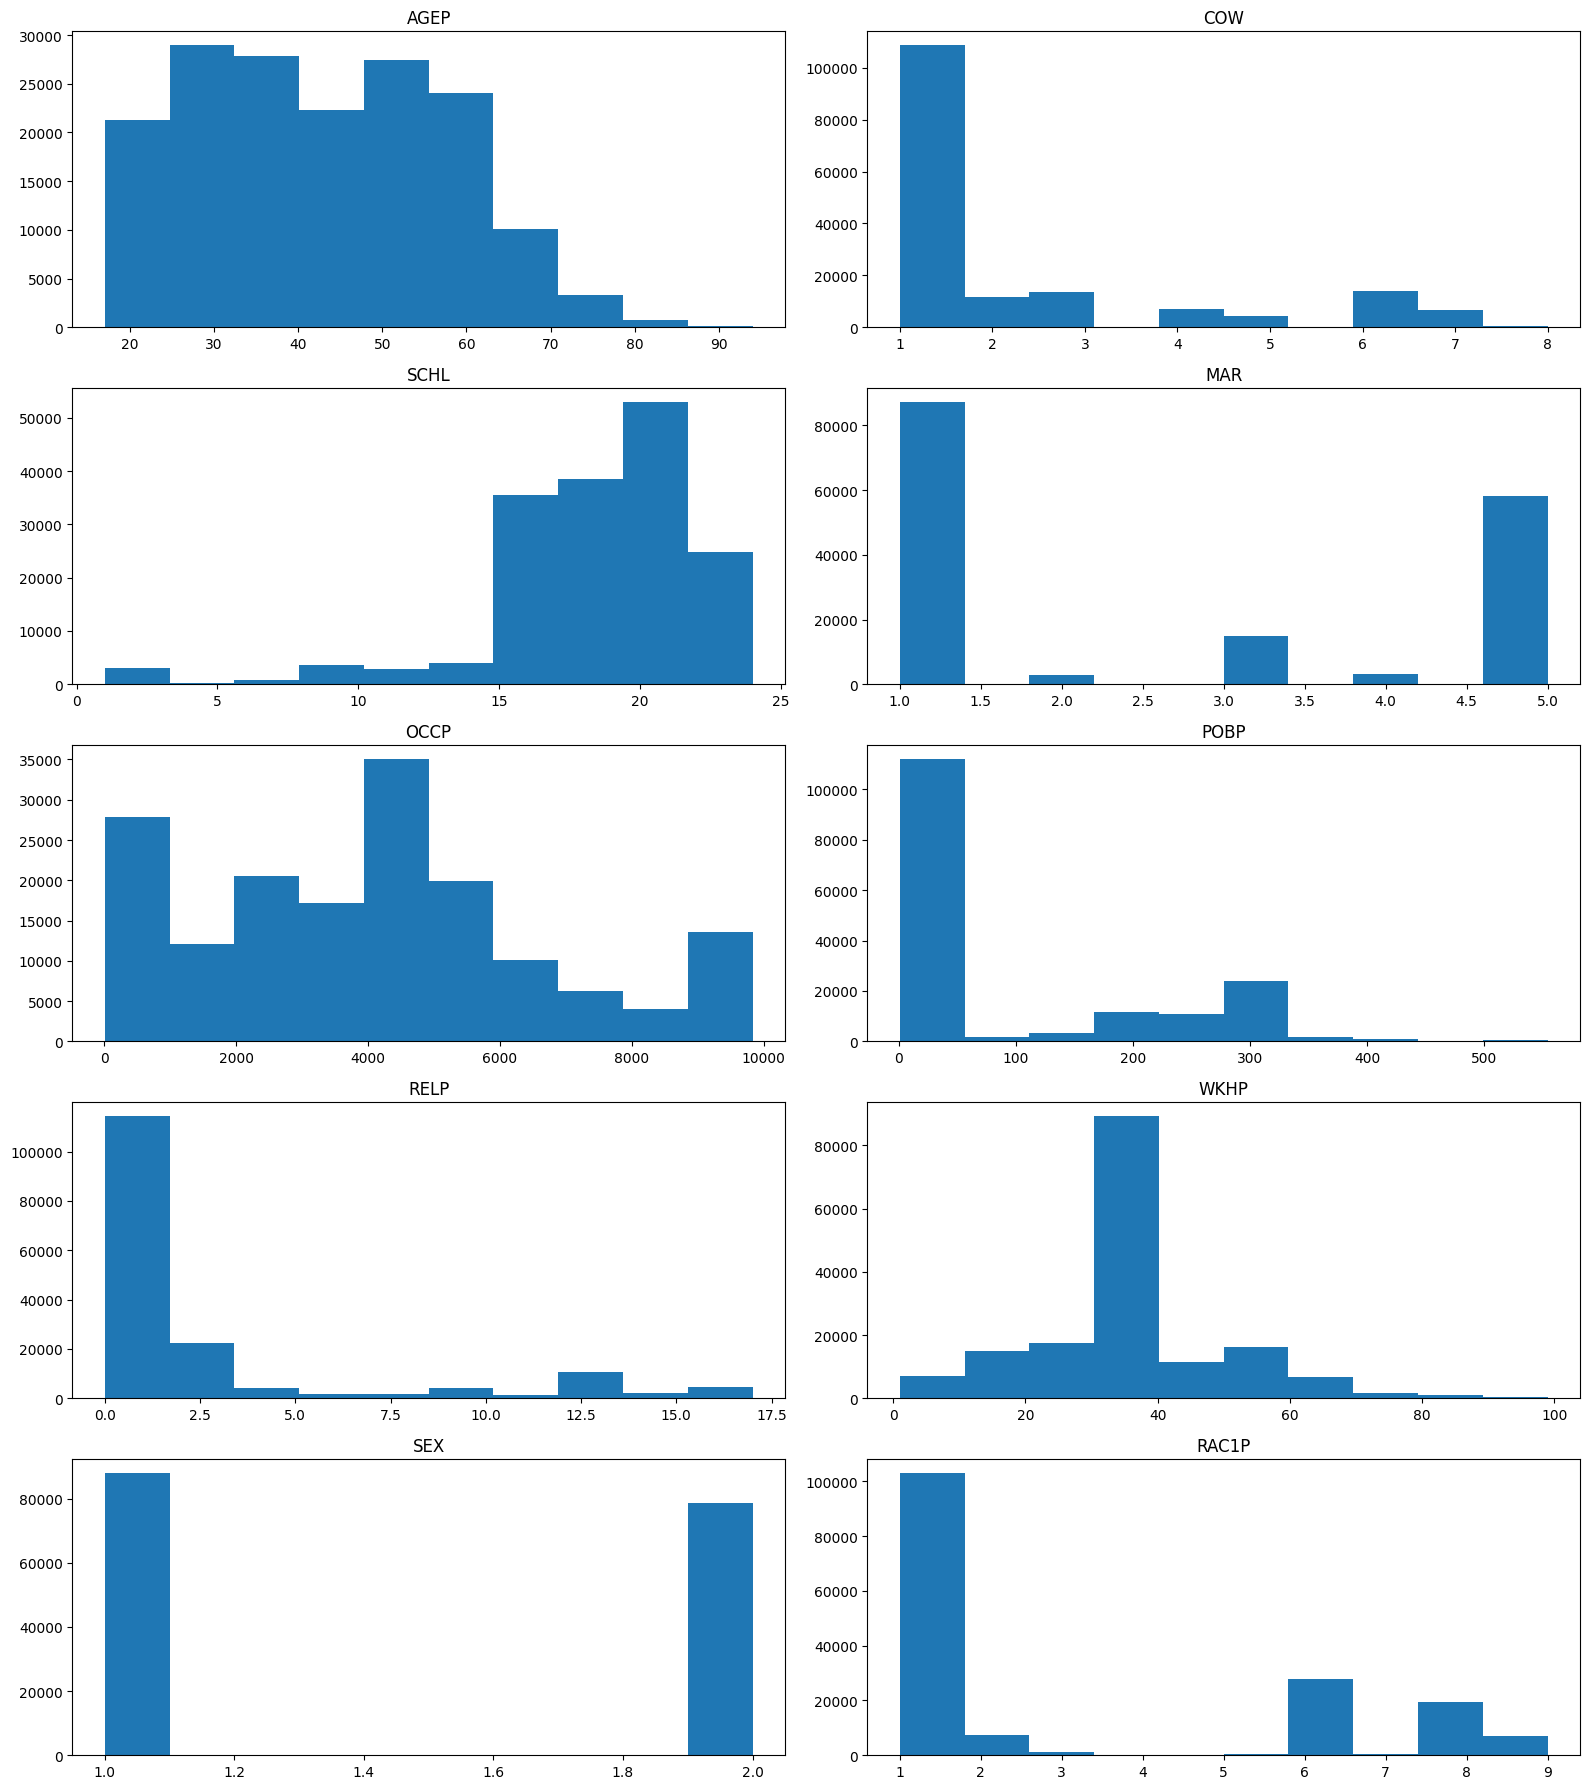

In [7]:
import matplotlib.pyplot as plt

num_cols = len(features.columns)
nrows = num_cols // 2 + num_cols % 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 18))
axes = axes.flatten()

for i in range(num_cols):
    axes[i].hist(features.iloc[:, i])
    axes[i].set_title(features.columns[i])

for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

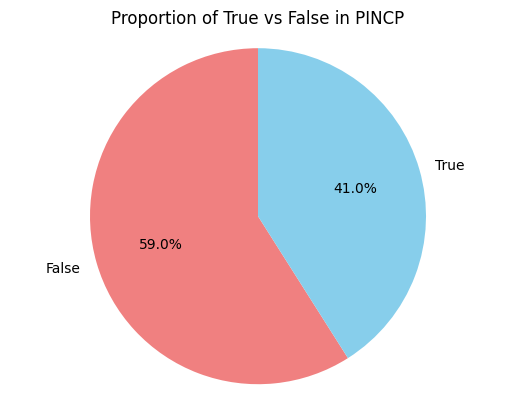

In [8]:
counts = labels['PINCP'].value_counts()

plt.pie(counts, labels=counts.index.astype(str), autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title('Proportion of True vs False in PINCP')
plt.axis('equal')

plt.show()

In [9]:
subdataset_of_trues = dataset[dataset["PINCP"] == True]
subdataset_of_trues.head()
subdataset_of_trues.shape

(68203, 11)

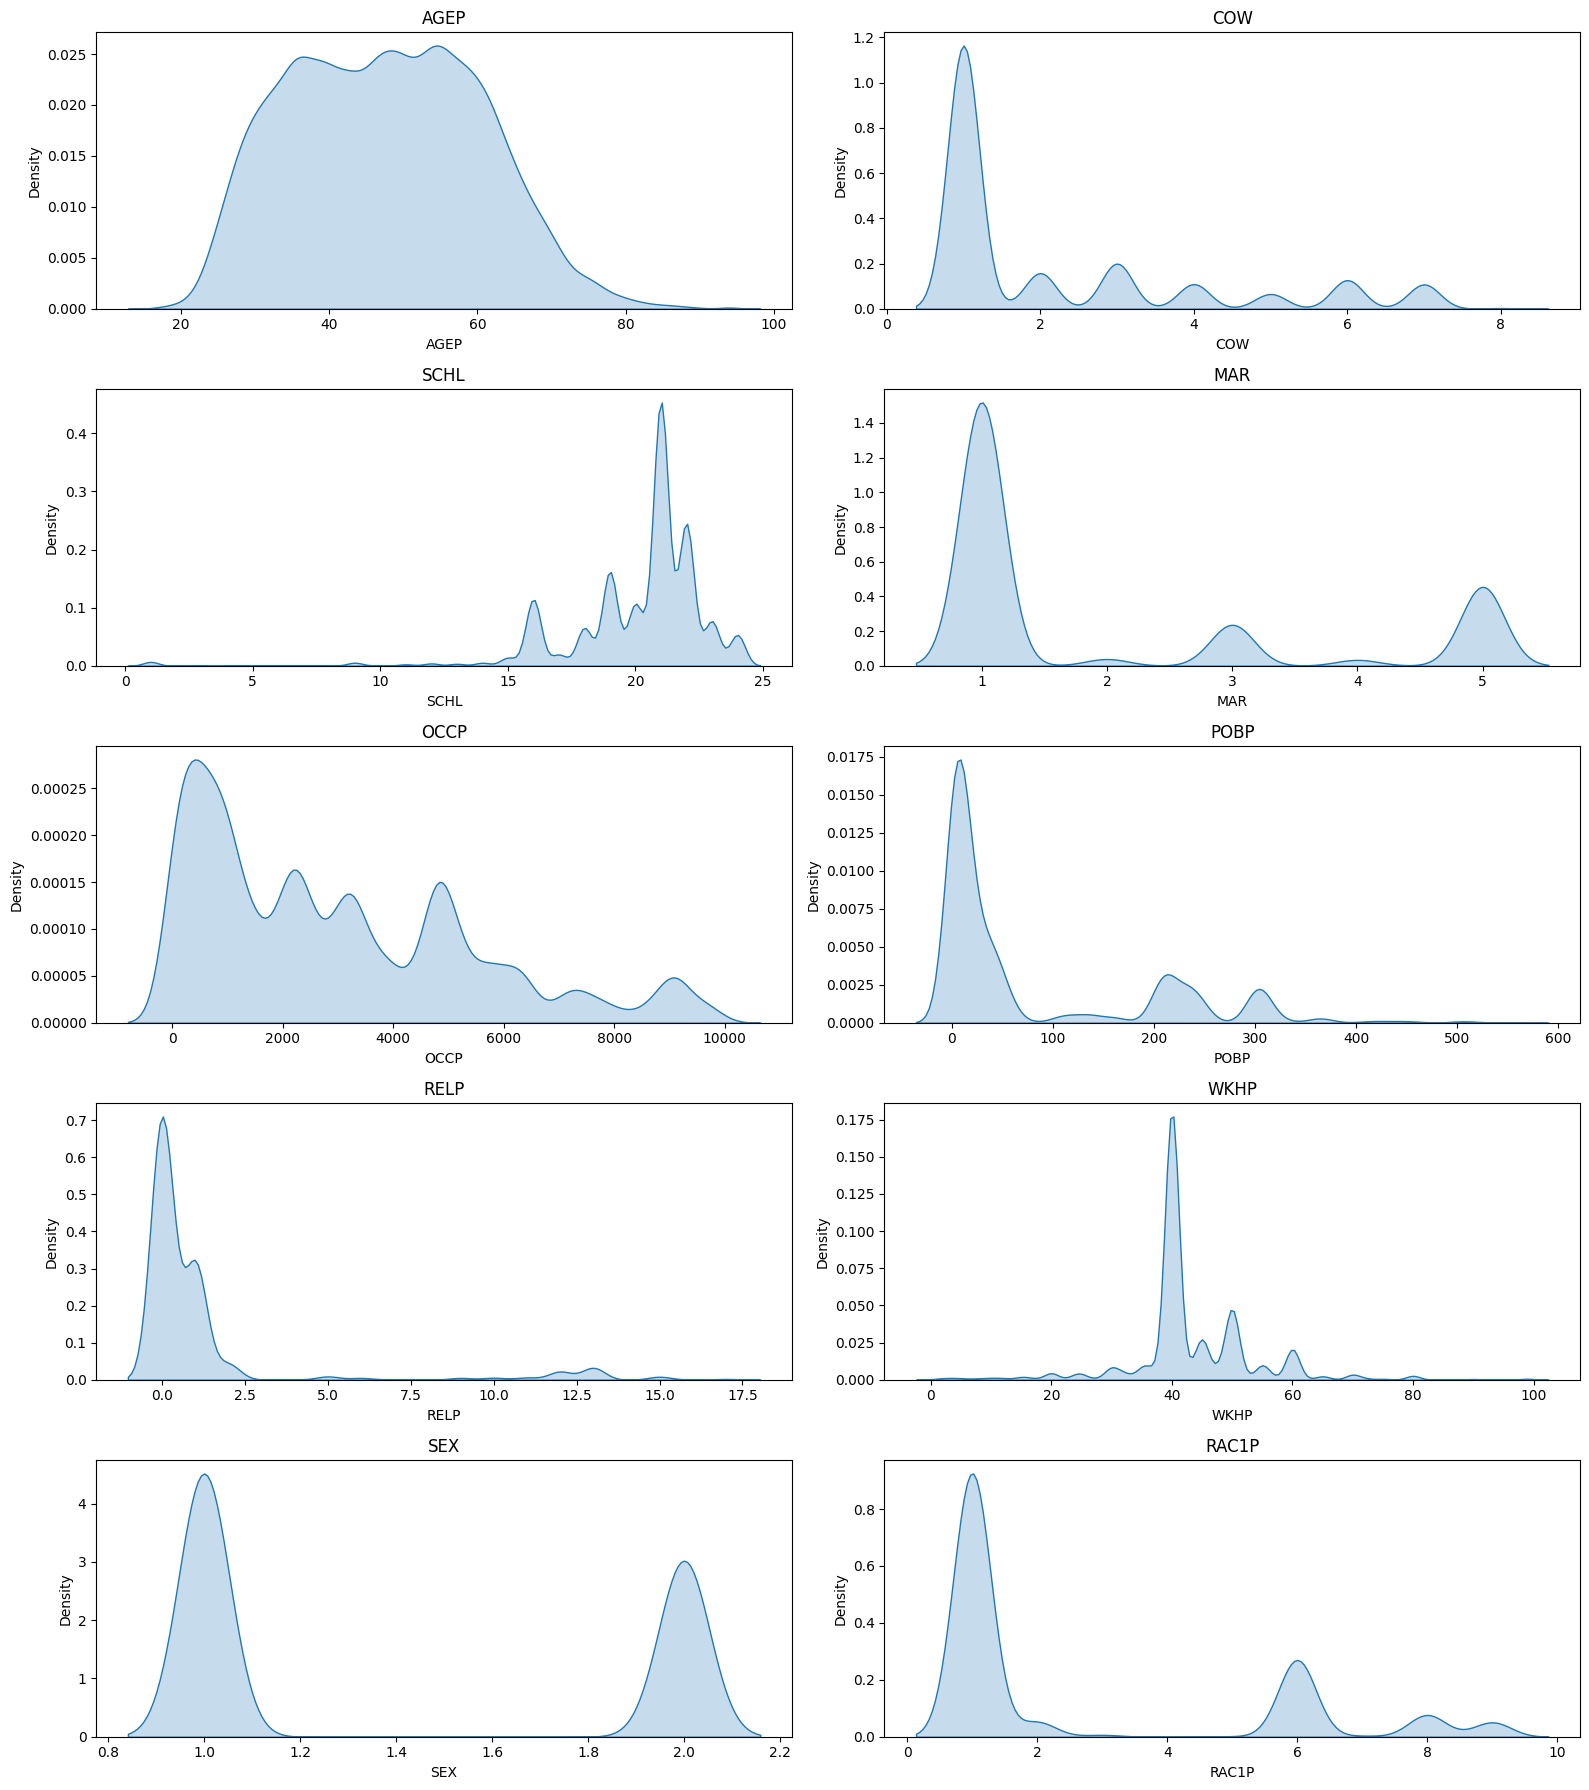

In [10]:
import seaborn as sns

subfeatures_of_trues = subdataset_of_trues.drop(columns=["PINCP"])
num_cols = len(subfeatures_of_trues.columns)
nrows = num_cols // 2 + num_cols % 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 18))
axes = axes.flatten()

for i in range(num_cols):
    sns.kdeplot(subfeatures_of_trues.iloc[:, i], ax=axes[i], shade=True)
    axes[i].set_title(subfeatures_of_trues.columns[i])

for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

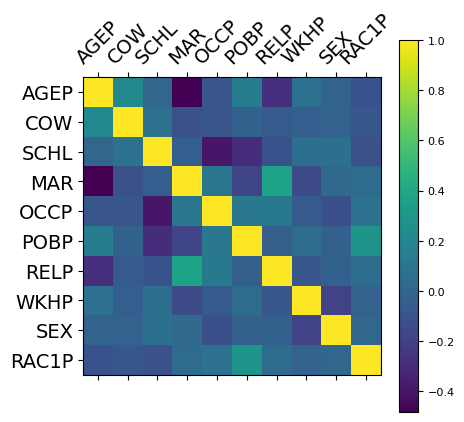

In [11]:
plt.matshow(features.corr())
plt.xticks(range(features.select_dtypes(['number']).shape[1]), features.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(features.select_dtypes(['number']).shape[1]), features.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=8)
plt.show()

In [12]:
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ["COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "SEX", "RAC1P"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
features_to_encode = features[columns_to_encode]

encoded_features_array = encoder.fit_transform(features_to_encode)
encoded_features_columns = encoder.get_feature_names_out(columns_to_encode)
encoded_features = pd.DataFrame(encoded_features_array, columns=encoded_features_columns, index=features.index)

features_remaining = features.drop(columns=columns_to_encode)
features_encoded = pd.concat([features_remaining, encoded_features], axis=1)
features_encoded.head()

,AGEP,WKHP,COW_1.0,COW_2.0,COW_3.0,COW_4.0,COW_5.0,COW_6.0,COW_7.0,COW_8.0,...,SEX_2.0,RAC1P_1.0,RAC1P_2.0,RAC1P_3.0,RAC1P_4.0,RAC1P_5.0,RAC1P_6.0,RAC1P_7.0,RAC1P_8.0,RAC1P_9.0
0,41.0,60.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,77.0,35.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38.0,50.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,30.0,80.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,36.0,70.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(features_encoded, labels, test_size=0.3, train_size=0.7)
print(features_train.shape)
print(features_test.shape)
print(labels_train.shape)
print(labels_test.shape)

(116420, 816)
(49895, 816)
(116420, 1)
(49895, 1)


## 2. Random Forest

### 2.1 Qualité d'apprentissage avec le paramétrage par défaut (Expe 1)

| Expérimentation 1     | Train   | Test   |
|-----------------------|---------|--------|
| Taille Jeu de Données | 116420  | 49895  |


In [14]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score
"""
random_forest = RandomForestClassifier()
ada_boost = AdaBoostClassifier()
xg_boost = GradientBoostingClassifier()

for model in [random_forest, ada_boost, xg_boost]:
    print(model)
    validation_result = cross_validate(model, features_train, labels_train)
    
    print("Cross-validation Fit Times:", np.mean(validation_result["fit_time"]))
    
    model.fit(features_train, labels_train)
    
    train_prediction = model.predict(features_train)
    train_accuracy = accuracy_score(labels_train, train_prediction)
    train_confusion_matrix = confusion_matrix(labels_train, train_prediction)
    
    print("Training Accuracy:", train_accuracy)
    print("Training Confusion Matrix:\n", train_confusion_matrix)
    
    test_prediction = model.predict(features_test)
    test_accuracy = accuracy_score(labels_test, test_prediction)
    test_confusion_matrix = confusion_matrix(labels_test, test_prediction)

    print("Test Accuracy:", test_accuracy)
    print("Test Confusion Matrix:\n", test_confusion_matrix)

    print("=======================")
"""

'\nrandom_forest = RandomForestClassifier()\nada_boost = AdaBoostClassifier()\nxg_boost = GradientBoostingClassifier()\n\nfor model in [random_forest, ada_boost, xg_boost]:\n    print(model)\n    validation_result = cross_validate(model, features_train, labels_train)\n\n    print("Cross-validation Fit Times:", np.mean(validation_result["fit_time"]))\n\n    model.fit(features_train, labels_train)\n\n    train_prediction = model.predict(features_train)\n    train_accuracy = accuracy_score(labels_train, train_prediction)\n    train_confusion_matrix = confusion_matrix(labels_train, train_prediction)\n\n    print("Training Accuracy:", train_accuracy)\n    print("Training Confusion Matrix:\n", train_confusion_matrix)\n\n    test_prediction = model.predict(features_test)\n    test_accuracy = accuracy_score(labels_test, test_prediction)\n    test_confusion_matrix = confusion_matrix(labels_test, test_prediction)\n\n    print("Test Accuracy:", test_accuracy)\n    print("Test Confusion Matrix:\n"

| Résultats en entraînement <br/> (hyper-param par défaut) | Random Forest   | AdaBoost   | XGBoost |
|----------------------------------------------------------|-----------------|------------|---------|
| accuracy                                                 |       0.998     |     0.779  |  0.803  |
| temps de calcul (sec.)                                   |       47.4      |     16.2   |   58.9  |
| matrice de confusion                                     |       [68543&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;109]<br/>[90&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;47678]          |   [57064&nbsp;&nbsp;11588]<br/>[14189&nbsp;&nbsp;33579]         |   [58161&nbsp;&nbsp;10491]<br/>[12446&nbsp;&nbsp;35322]      |

<hr />

| Résultats en test <br/> (hyper-param par défaut) | Random Forest   | AdaBoost   | XGBoost |
|--------------------------------------------------|-----------------|------------|---------|
| accuracy                                         |     0.811       |    0.778   |   0.801 |
| matrice de confusion                             |     [25159&nbsp;&nbsp;4301]<br/>[5152&nbsp;&nbsp;15283]            |  [24469&nbsp;&nbsp;4991]<br/>[6070&nbsp;&nbsp;14365]          |   [24943&nbsp;&nbsp;4517]<br/>[5395&nbsp;&nbsp;15040]      |

### 2.2 Optimisation des hyperparamètres des modèles (Expe 2) 

| Expérimentation 1     | Train   | Test   |
|-----------------------|---------|--------|
| Taille Jeu de Données | 116420  | 49895  |


#### 1. Liste des hyperparamètres

##### a) Random Forest

- **n_estimators**: 100, 300, 500
- **max_depth**: None, 10, 20
- **min_samples_split**: 2, 5
- **max_features**: sqrt, log2

##### b) AdaBoost

- **n_estimators**: 50, 100, 200
- **learning_rate**: 0.5, 1.0
- **estimator.max_depth**: 1, 2

##### c) XGBoost

- **n_estimators**: 200, 500
- **max_depth**: 3, 6
- **learning_rate**: 0.05, 0.1
- **sub_sample**: 0.8, 1.0
- **loss**: log_loss, exponential

#### 2. Nombre de plis dans la validation croisée

On garde la valeur par défaut de Scikit-Learn: **5 plis**

#### 3. Estimation du nombre d'entraînements

Nombre d'entraînements par pli:

* **Random Forest**: 3 * 3 * 2 * 2 = **36**
* **AdaBoost**: 3 * 2 * 2 = **12**
* **XGBoost**: 2 * 2 * 2 * 2 * 2 = **32**

Vu qu'il y a 5 plis, le nombre total d'entraînements sera donc: 5 * 36 + 5 * 12 * 5 * 32 = **400 entraînements**


In [15]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

"""
items = [
    (
        RandomForestClassifier, 
        {
            "n_estimators": [100, 300, 500],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5],
            "max_features": ["sqrt", "log2"],
        }
    ),
    (
        AdaBoostClassifier,
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.5, 1.0],
            "estimator": [
                DecisionTreeClassifier(max_depth=2),
                DecisionTreeClassifier(max_depth=3)
            ]
        }
    ),
    (
        GradientBoostingClassifier,
        {
            "n_estimators": [200, 500],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "loss": ["log_loss", "exponential"],
        }
    ),
]


for ModelClass, params in items:
    model = ModelClass()
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        verbose=2
    )

    start = time.time()
    grid.fit(features_train, labels_train)
    end = time.time()
    
    print(f"===== {ModelClass} =====")
    print("Best params:", grid.best_params_)
    print("Best score:", grid.best_score_)
    print("Time:", end - start)
    
    labels_pred = grid.predict(features_test)
    print("Accuracy:", accuracy_score(labels_test, labels_pred))
    print(confusion_matrix(labels_test, labels_pred))
"""

'\nitems = [\n    (\n        RandomForestClassifier, \n        {\n            "n_estimators": [100, 300, 500],\n            "max_depth": [None, 10, 20],\n            "min_samples_split": [2, 5],\n            "max_features": ["sqrt", "log2"],\n        }\n    ),\n    (\n        AdaBoostClassifier,\n        {\n            "n_estimators": [50, 100, 200],\n            "learning_rate": [0.5, 1.0],\n            "estimator": [\n                DecisionTreeClassifier(max_depth=2),\n                DecisionTreeClassifier(max_depth=3)\n            ]\n        }\n    ),\n    (\n        GradientBoostingClassifier,\n        {\n            "n_estimators": [200, 500],\n            "max_depth": [3, 6],\n            "learning_rate": [0.05, 0.1],\n            "subsample": [0.8, 1.0],\n            "loss": ["log_loss", "exponential"],\n        }\n    ),\n]\n\n\nfor ModelClass, params in items:\n    model = ModelClass()\n\n    grid = GridSearchCV(\n        estimator=model,\n        param_grid=params,\n      

|                               | Train Accuracy | CPU Time | Test Accuracy  | Hyperparamètres  |
|-------------------------------|----------------|----------|----------------|------------------|
| Random Forest (par défaut)    | 0.998          | 47.4s    | 0.811          | defaults sklearn |
| Random Forest (optimisé)      | 0.819          | 30min    | 0.818          | max_depth: None<br/>max_features: "log2"<br/> min_samples_split: 5<br/> n_estimators: 300              |



|                           | Train Accuracy | CPU Time | Test Accuracy  | Hyperparamètres  |
|---------------------------|----------------|----------|----------------|------------------|
| AdaBoost (par défaut)     | 0.779          | 16.2     | 0.778          | defaults sklearn |
| AdaBoost (optimisé)       | 0.804          | 20min    | 0.805          | estimator: DecisionTreeClassifier(max_depth=3)<br/> learning_rate: 1.0<br/> n_estimators: 200             |


|                           | Train Accuracy | CPU Time | Test Accuracy  | Hyperparamètres  |
|---------------------------|----------------|----------|----------------|------------------|
| XGBoost (par défaut)      | 0.803          | 58.9     | 0.801          | defaults         |
| XGBoost (optimisé)        | 0.825          | 34min    | 0.823          | learning_rate: 0.1<br/> loss: "exponential"<br/> max_depth: 6<br/> n_estimators: 500<br/> subsample: 0.8              |

### 2.3 Analyse des résultats (Expe 3)

| Résultats en entraînement <br/> (hyper-param optimisés)  | Random Forest   | AdaBoost   | XGBoost |
|----------------------------------------------------------|-----------------|------------|---------|
| accuracy                                                 |       0.819     |     0.804  |  0.825  |
| temps de calcul (sec.)                                   |       10s       |     20s    |   13s   |

| Résultats en test <br/> (hyper-param optimisés)  | Random Forest   | AdaBoost   | XGBoost |
|--------------------------------------------------|-----------------|------------|---------|
| accuracy                                         |     0.818       |    0.805   |   0.823 |
| matrice de confusion                             |     [25284&nbsp;&nbsp;3992]<br/>[5080&nbsp;&nbsp;15539]            |  [24535&nbsp;&nbsp;4741]<br/>[4970&nbsp;&nbsp;15649]          |   [25080&nbsp;&nbsp;4321]<br/>[4495&nbsp;&nbsp;15999]      |

### 2.4 Inférence sur un autre jeu de données (Expe 4)

In [16]:
from xgboost import XGBClassifier

def get_best_random_forest():
    return RandomForestClassifier(
        max_depth=None, 
        max_features="log2", 
        min_samples_split=5, 
        n_estimators=300, 
        n_jobs=-1
    )

def get_best_ada_boost():
    return AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3), 
        learning_rate=1.0, 
        n_estimators=200
    )

def get_best_xg_boost():
    return XGBClassifier(
        learning_rate=0.1, 
        loss="exponential", 
        max_depth=6, 
        n_estimators=500, 
        subsample=0.8, 
        tree_method="hist", 
        device="cuda", 
        n_jobs=1
    )

def get_best_models():
    return {
        "RandomForest": get_best_random_forest(),
        "AdaBoost": get_best_ada_boost(),
        "XGBoost": get_best_xg_boost(),
    }

In [17]:
models_dict = get_best_models()

for model_name, model in models_dict.items():
    print(f"Fitting {model_name} on State CA")
    model.fit(features_train, labels_train)

Fitting RandomForest on State CA
Fitting AdaBoost on State CA
Fitting XGBoost on State CA


In [18]:
for state in ["co", "ne"]:
    print(f"Encoding dataset for State {state.upper()} ==============================================================")
    
    state_features = pd.read_csv(f"data/acsincome_{state}_allfeatures.csv")
    print(state_features.head())
    
    state_labels = pd.read_csv(f"data/acsincome_{state}_label.csv")
    print(state_labels.head())

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    state_features_to_encode = state_features[columns_to_encode]

    encoded_state_features_array = encoder.fit_transform(state_features_to_encode)
    encoded_state_features_columns = encoder.get_feature_names_out(columns_to_encode)
    encoded_state_features = pd.DataFrame(encoded_state_features_array, columns=encoded_state_features_columns, index=state_features.index)
    
    state_features_remaining = state_features.drop(columns=columns_to_encode)
    state_features_encoded = pd.concat([state_features_remaining, encoded_state_features], axis=1)
 
    # Add missing columns with value 0
    state_features_encoded = state_features_encoded.reindex(
        columns=features_encoded.columns,
        fill_value=0.0
    )
    
    print(state_features_encoded.head())

    for model_name, model in models_dict.items():
        print(f"Predicting with {model_name} on State {state.upper()}")
        
        state_prediction = model.predict(state_features_encoded)
        state_accuracy = accuracy_score(state_labels, state_prediction)
        state_confusion_matrix = confusion_matrix(state_labels, state_prediction)
    
        print("Accuracy:", state_accuracy)
        print("Confusion Matrix:\n", state_confusion_matrix)
    
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

Encoding dataset for State CO ==============================================================
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P
0  19.0  2.0  19.0  5.0  2850.0   6.0  17.0   2.0  2.0    9.0
1  24.0  5.0  18.0  5.0  9645.0  13.0  17.0  40.0  1.0    2.0
2  22.0  1.0  19.0  5.0  1520.0  53.0  17.0  45.0  2.0    1.0
3  32.0  1.0  16.0  1.0  4055.0   8.0  16.0  40.0  2.0    1.0
4  19.0  2.0  19.0  5.0  2006.0  34.0  17.0   9.0  2.0    1.0
   PINCP
0      0
1      0
2      0
3      0
4      0
   AGEP  WKHP  COW_1.0  COW_2.0  COW_3.0  COW_4.0  COW_5.0  COW_6.0  COW_7.0  \
0  19.0   2.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
1  24.0  40.0      0.0      0.0      0.0      0.0      1.0      0.0      0.0   
2  22.0  45.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
3  32.0  40.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
4  19.0   9.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   



Les résultats obtenus sur les états de Nevada et Colorado se situent entre 0,73 et 0,79 d'accuracy : 

|  Etat / Accuracy            | Random Forest   | AdaBoost   | XGBoost |
|-----------------------------|-----------------|------------|---------|
| Californie (entraînement)   |       0.818     |     0.805  |  0.823  |
| Colorado                    |       0.782     |     0.768  |  0.787  |
| Nevada                      |       0.751     |     0.728  |  0.748  |

Ceci est certainement dû au fait qu'en fonction des états, les niveaux de vie diffèrent, de même que les paramètres qui influent sur eux. Un modèle entrainé sur un état X peut donc ne pas performer sur un état Y.

### 2.5 Impact de la taille du jeu de données (Expe 5)

In [19]:
models_dict_2 = get_best_models()
train_sizes = [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]
results = {
    model_name: {
        "train_accuracy": [],
        "test_accuracy": [],
        "fit_time": [],
        "confusion_matrix": [],
    }
    for model_name in models_dict_2
}

for train_size in train_sizes:
    print(f"Results for train_size={train_size} ==============================")
    
    features_train, features_test, labels_train, labels_test = train_test_split(
        features_encoded, 
        labels, 
        test_size=1-train_size, 
        train_size=train_size
    )
    
    for model_name, model in models_dict_2.items():
        print(f"Processing: {model_name}")
        
        cross_validation_result = cross_validate(
            model, 
            features_train, 
            labels_train, 
            n_jobs=-1 if "AdaBoost" in model_name else 1
        )
        results[model_name]["fit_time"].append(np.mean(cross_validation_result["fit_time"]))
        print(f'Cross-validation Fit Times: {results[model_name]["fit_time"][-1]}')
        
        model.fit(features_train, labels_train)
        
        train_prediction = model.predict(features_train)
        
        train_accuracy = accuracy_score(labels_train, train_prediction)
        results[model_name]["train_accuracy"].append(train_accuracy)
        print(f'Training Accuracy: {results[model_name]["train_accuracy"][-1]}')

        test_prediction = model.predict(features_test)
        
        test_accuracy = accuracy_score(labels_test, test_prediction)
        results[model_name]["test_accuracy"].append(test_accuracy)
        print(f'Test Accuracy: {results[model_name]["test_accuracy"][-1]}')
        
        test_confusion_matrix = confusion_matrix(labels_test, test_prediction)
        
        test_confusion_matrix_norm = test_confusion_matrix / test_confusion_matrix.sum(axis=1, keepdims=True)
        results[model_name]["confusion_matrix"].append(test_confusion_matrix_norm)
        print(f'Test Confusion Matrix:\n{results[model_name]["confusion_matrix"][-1]}')
    
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

Results for train_size=0.8 ==============================
Processing: RandomForest
Cross-validation Fit Times: 6.6050842761993405
Training Accuracy: 0.9688768301115354
Test Accuracy: 0.8212728857890148
Test Confusion Matrix:
[[0.86318918 0.13681082]
 [0.2382338  0.7617662 ]]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Processing: AdaBoost
Cross-validation Fit Times: 151.75256452560424
Training Accuracy: 0.8055121305955566
Test Accuracy: 0.8059705979616992
Test Confusion Matrix:
[[0.83782537 0.16217463]
 [0.2392522  0.7607478 ]]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Processing: XGBoost
Cross-validation Fit Times: 8.120733070373536
Training Accuracy: 0.8394612632654902
Test Accuracy: 0.826954874785798
Test Confusion Matrix:
[[0.85150646 0.14849354]
 [0.20789991 0.79210009]]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Results for train_size=0.7 ==============================
Processing: RandomForest
Cross-validation Fit Times: 5.571624279022217
Training Accuracy: 0.9688627383611064
Test Accu

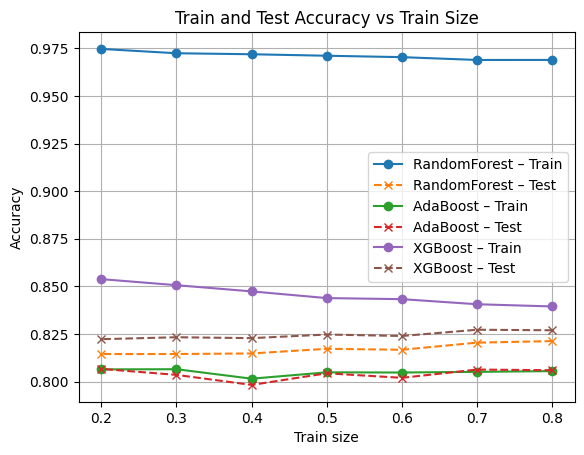

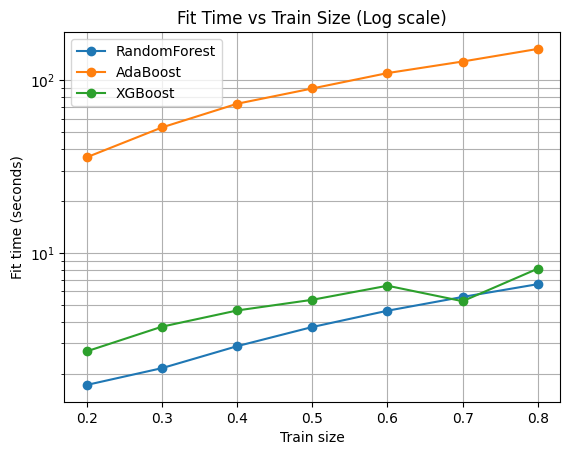

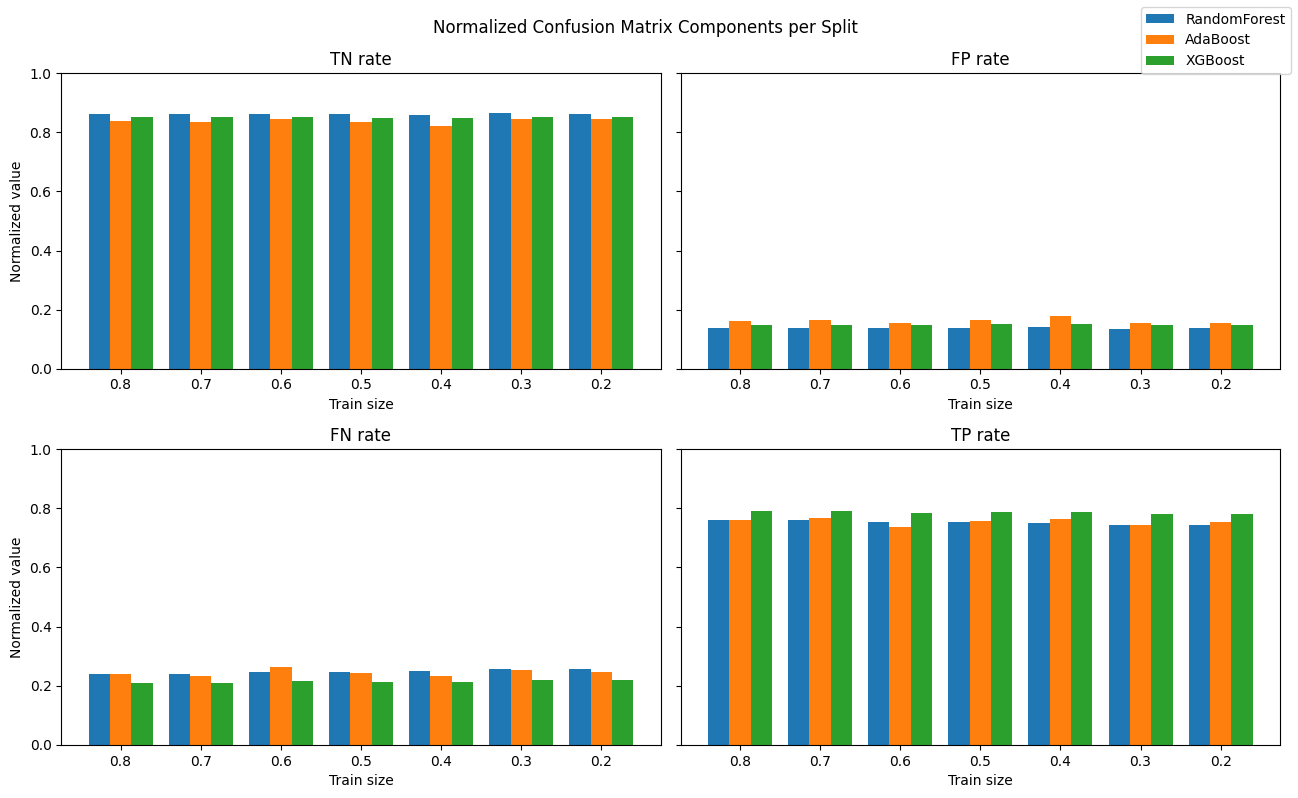

In [20]:
plt.figure()

for model_name, data in results.items():
    plt.plot(train_sizes, data["train_accuracy"], marker="o", label=f"{model_name} – Train")
    plt.plot(train_sizes, data["test_accuracy"], marker="x", linestyle="--", label=f"{model_name} – Test")

plt.xlabel("Train size")
plt.ylabel("Accuracy")
plt.title("Train and Test Accuracy vs Train Size")
plt.legend()
plt.grid(True)
plt.show()

# --------------------

plt.figure()

for model_name, data in results.items():
    plt.plot(train_sizes, data["fit_time"], marker="o", label=model_name)

plt.xlabel("Train size")
plt.ylabel("Fit time (seconds)")
plt.yscale("log")
plt.title("Fit Time vs Train Size (Log scale)")
plt.legend()
plt.grid(True, which="both")
plt.show()

# --------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

cells = [(0, 0), (0, 1), (1, 0), (1, 1)]
cell_names = ["TN rate", "FP rate", "FN rate", "TP rate"]
model_names = list(results.keys())
n_models = len(model_names)
n_splits = len(train_sizes)
bar_width = 0.8 / n_models
x = np.arange(n_splits)

for ax, (i, j), title in zip(axes.flat, cells, cell_names):
    for m_idx, model_name in enumerate(model_names):
        values = [
            results[model_name]["confusion_matrix"][s][i, j]
            for s in range(n_splits)
        ]
        ax.bar(
            x + m_idx * bar_width,
            values,
            width=bar_width,
            label=model_name if ax is axes.flat[0] else None,
        )

    ax.set_title(title)
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(train_sizes)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Train size")

axes[0, 0].set_ylabel("Normalized value")
axes[1, 0].set_ylabel("Normalized value")

fig.suptitle("Normalized Confusion Matrix Components per Split")
fig.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 3. Explicabilité des prédictions


Pour la suite, nous choisissons le modèle Random Forest.

In [17]:
model = get_best_xg_boost()
model.fit(features_train, labels_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 3.1 Classement des attributs dans la prédiction

In [27]:
from sklearn.inspection import permutation_importance

reduced_sample_size = min(2000, len(features_test))
reduced_sample_indices = np.random.choice(features_test.index, reduced_sample_size, replace=False)

features_reduced = features_test.loc[reduced_sample_indices]
labels_reduced = labels_test.loc[reduced_sample_indices]

result = permutation_importance(
    model,
    features_reduced,
    labels_reduced,
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

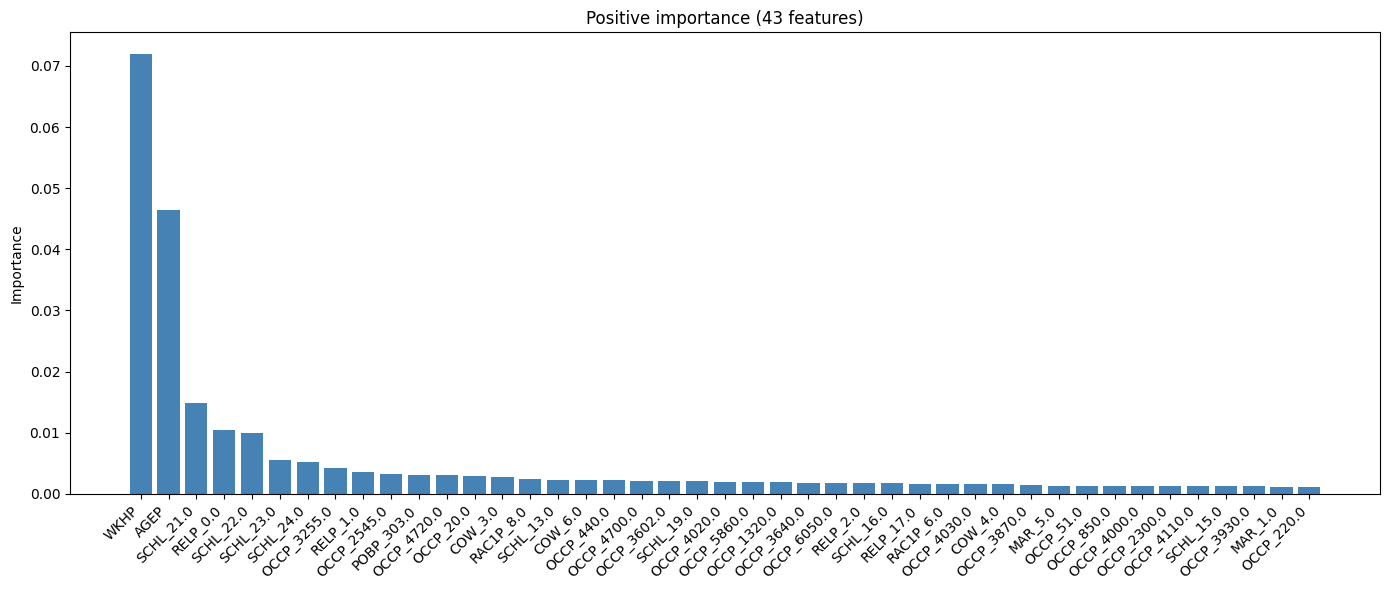

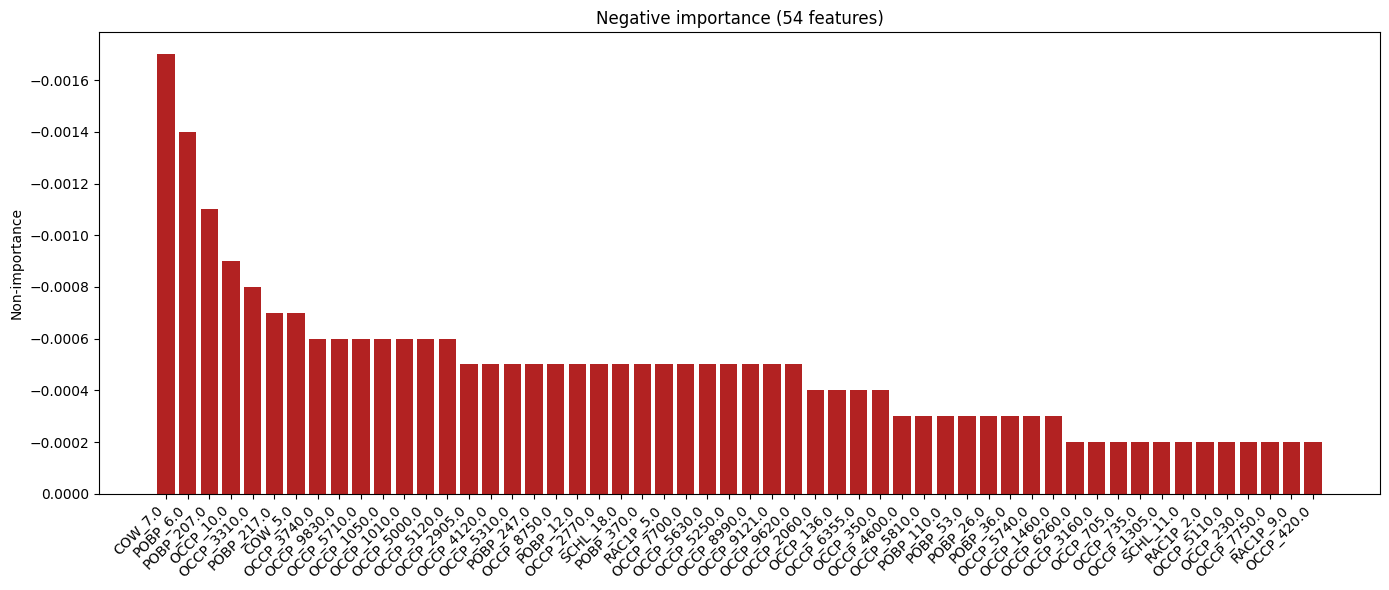

In [32]:
importances = result.importances_mean

positive_mask = importances > 0.001
positive_importances = importances[positive_mask]
positive_features = features_test.columns[positive_mask]

# Sort High to Low
positive_indices = np.argsort(positive_importances)[::-1]
sorted_positive_importances = positive_importances[positive_indices]
sorted_positive_features = positive_features[positive_indices]

plt.figure(figsize=(14, 6))
plt.bar(range(len(sorted_positive_features)), sorted_positive_importances, color="steelblue")
plt.xticks(
    range(len(sorted_positive_features)), 
    sorted_positive_features, 
    rotation=45,
    ha="right", 
    fontsize=10
)
plt.title(f"Positive importance ({len(sorted_positive_features)} features)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

negative_mask = importances < -0.0002
negative_importances = importances[negative_mask]
negative_features = features_test.columns[negative_mask]

# Sort Lowest (most negative) to Highest (closest to 0)
negative_indices = np.argsort(negative_importances) # Ascending sort puts most negative first
sorted_negative_importances = negative_importances[negative_indices]
sorted_negative_features = negative_features[negative_indices]

plt.figure(figsize=(14, 6))
plt.bar(range(len(sorted_negative_features)), sorted_negative_importances, color="firebrick")
plt.xticks(
    range(len(sorted_negative_features)), 
    sorted_negative_features, 
    rotation=45, 
    ha="right", 
    fontsize=10
)
plt.title(f"Negative importance ({len(sorted_negative_features)} features)")
plt.ylabel("Non-importance")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

### 3.2 Explications locales

#### Examples choisis (commun aux deux méthodes)

In [18]:
#samples_indices = np.random.choice(features_test.shape[0], size=3, replace=False)
#print(samples_indices)
samples_indices = [42248, 42931, 28117]
features_test.iloc[samples_indices]

,AGEP,WKHP,COW_1.0,COW_2.0,COW_3.0,COW_4.0,COW_5.0,COW_6.0,COW_7.0,COW_8.0,...,SEX_2.0,RAC1P_1.0,RAC1P_2.0,RAC1P_3.0,RAC1P_4.0,RAC1P_5.0,RAC1P_6.0,RAC1P_7.0,RAC1P_8.0,RAC1P_9.0
115593,33.0,30.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
84998,53.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
155921,70.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 1. Méthode LIME

In [19]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML, display

lime_explainer = LimeTabularExplainer(
    training_data=features_train.values,
    feature_names=features_train.columns,
    class_names=["<=50k", ">50k"],
    mode="classification"
)

for i in samples_indices:
    explaination = lime_explainer.explain_instance(
        features_test.iloc[i].values,
        model.predict_proba
    )
    display(HTML(explaination.as_html()))
    explaination.save_to_file(f"LIME_explaination_sample_{i}.html")

#### 2. Méthode SHAP

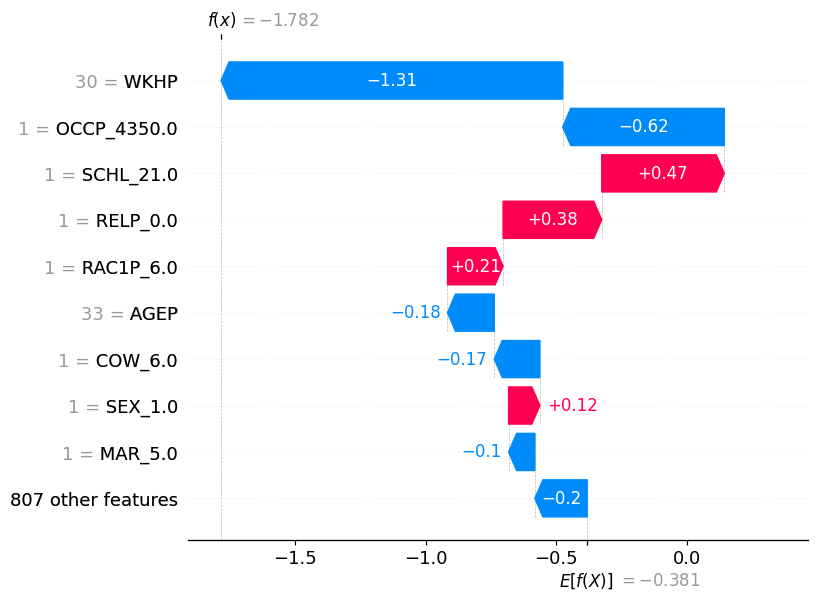

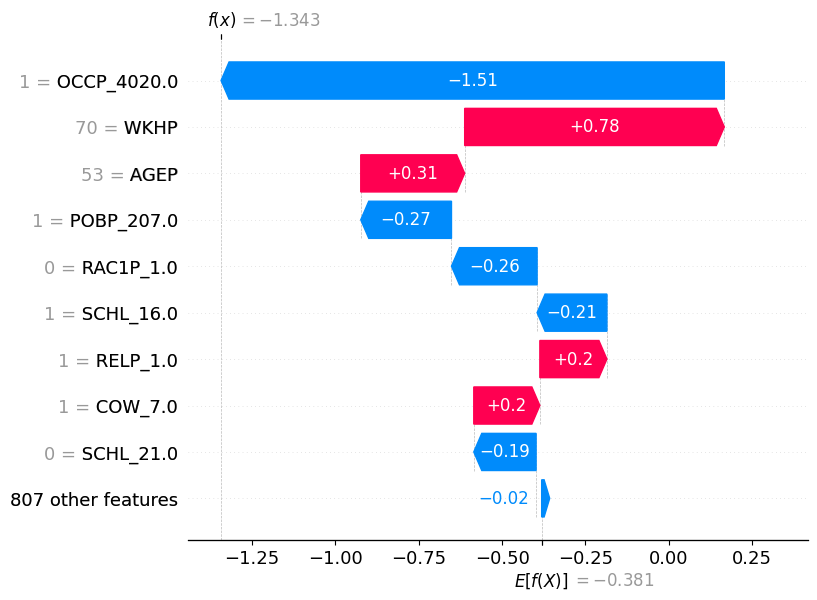

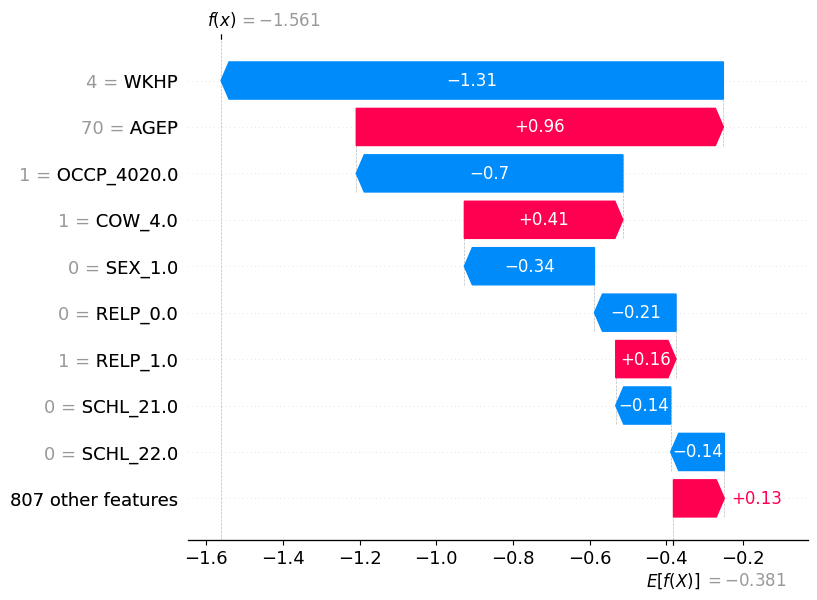

In [20]:
import shap

shap.initjs()

shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer(features_test)

for i in samples_indices:
    shap.plots.waterfall(shap_values[i])

#### 3. Comparaison LIME et SHAP

[TODO]

#### 4 & 5. Analyse Summary plot de SHAP

##### 4. Approfondissement 1: Global

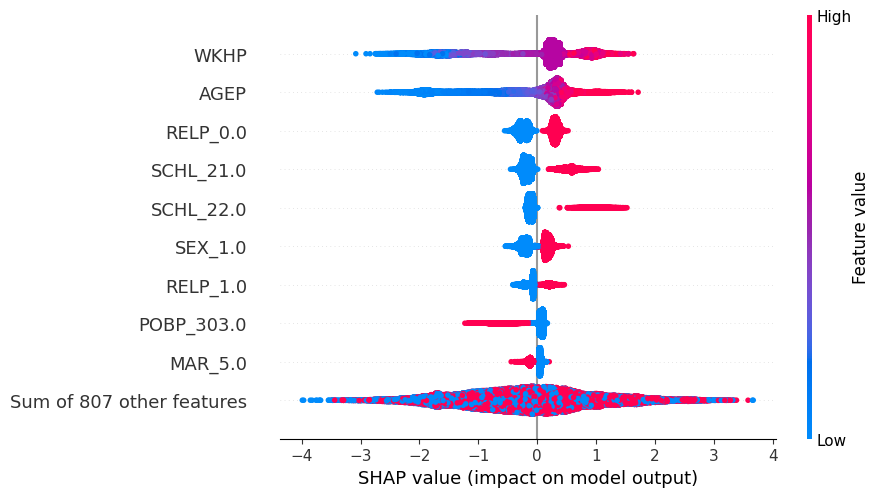

In [21]:
shap.plots.beeswarm(shap_values)

##### 5. Approfondissement 2: Par sous-groupes

TP


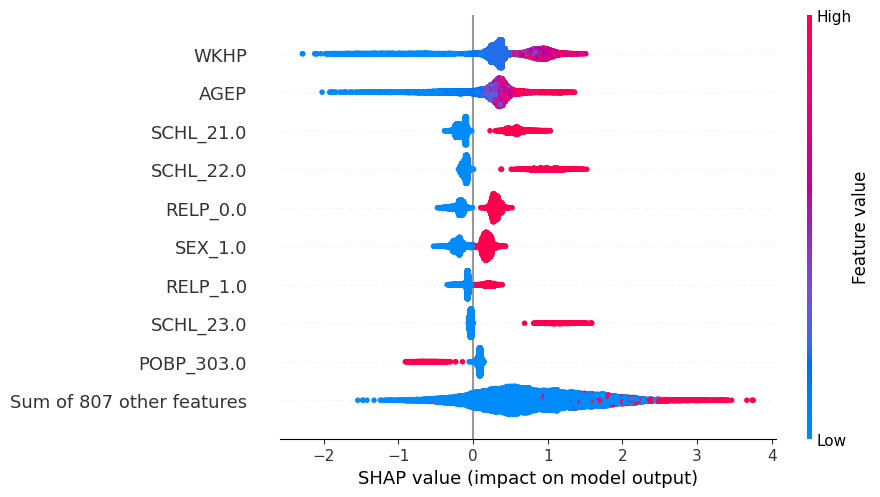

TN


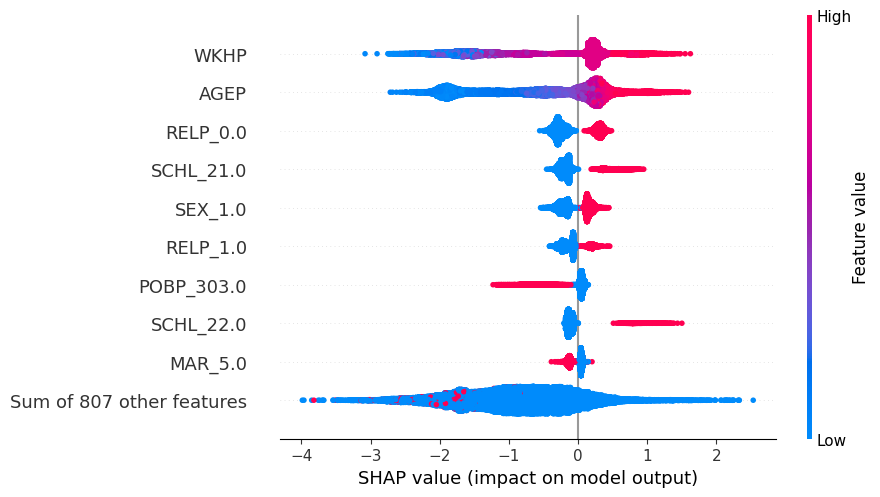

FP


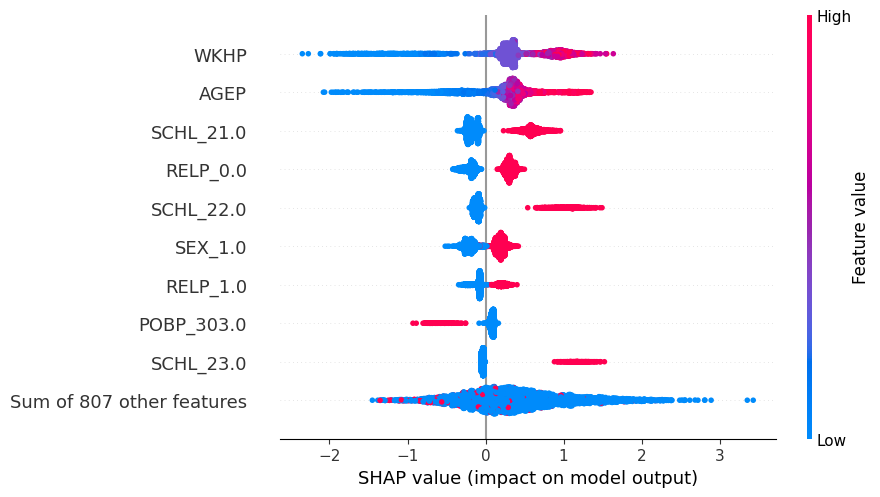

FN


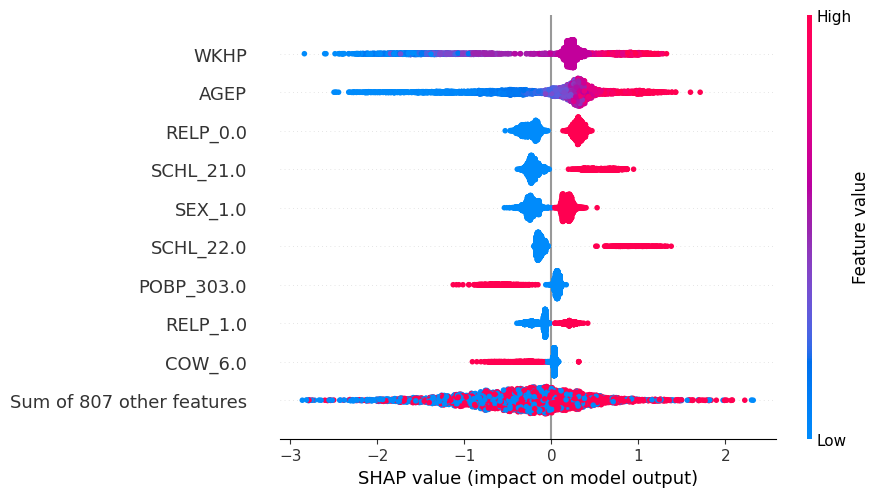

In [22]:
labels_pred = model.predict(features_test)

y_pred = labels_pred.squeeze()
y_test = labels_test.squeeze()

TP = features_test[(y_pred==1) & (y_test==1)]
TN = features_test[(y_pred==0) & (y_test==0)]
FP = features_test[(y_pred==1) & (y_test==0)]
FN = features_test[(y_pred==0) & (y_test==1)]

for name, group in [("TP",TP),("TN",TN),("FP",FP),("FN",FN)]:
    print(name)
    if len(group) > 0:
        shap_values_group = shap_explainer(group)
        shap.plots.beeswarm(shap_values_group)
    else:
        print("Aucun exemple dans le groupe")

### 3.3 Explication contrefactuelle